<center><h1>Sun_Yizhi_HW2</h1></center>
<br>
<br>

Name: Yizhi Sun
<br>
Github Username: yizhisun515
<br>
USC ID: 6129500198

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [2]:
from pathlib import Path

data_path = Path("data/Folds5x2_pp.xlsx")

if not data_path.exists():
    data_path = Path("../data/Folds5x2_pp.xlsx")

df = pd.read_excel(data_path, sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
num_rows, num_columns = df.shape

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")
print(f"Column names: {list(df.columns)}")

Number of rows: 9568
Number of columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']


The dataset contains 9,568 rows and 5 columns.

Each row represents one hourly observation from the power plant. The columns consist of four predictors (AT, V, AP, and RH) and one response variable (PE).

#### ii. pairwise scatterplots of all the varianbles

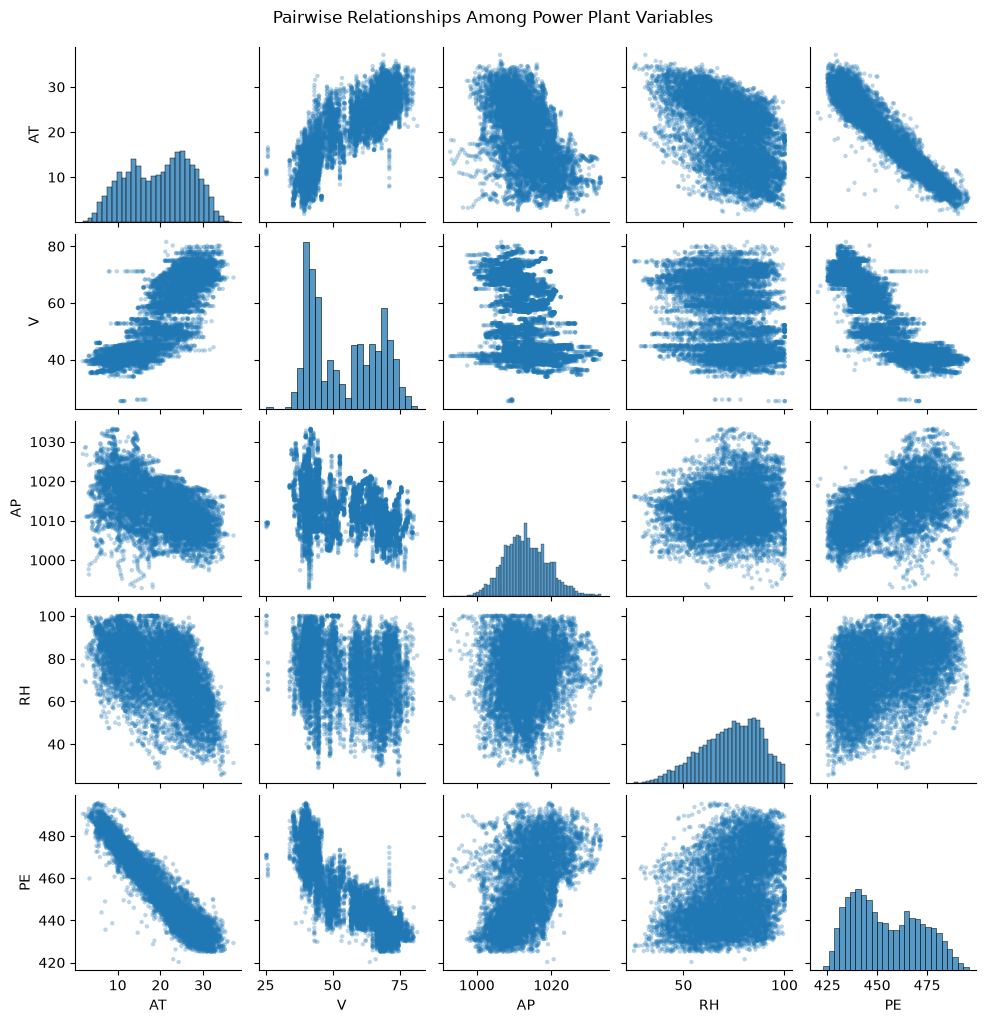

In [4]:
sns.pairplot(
    df,
    diag_kind="hist",
    height=2,
    plot_kws={"alpha": 0.3, "s": 10, "edgecolor": "none"}
)

plt.suptitle(
    "Pairwise Relationships Among Power Plant Variables",
    y=1.02
)
plt.show()

The pairwise scatterplots show several clear relationships among the variables.

PE has a strong negative relationship with AT, and it also decreases as V increases. AP shows a weaker positive association with PE, while RH appears to have a relatively weak relationship with PE.

Among the predictors, AT and V show a noticeable positive association, while AT and AP show a negative association. These relationships indicate that some predictors are correlated with one another and may have overlapping effects when used together in a multiple regression model.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.651231,20.345,1.81,37.11,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,25.36,81.56,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,992.89,1033.30,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,25.56,100.16,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,420.26,495.76,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

Simple Linear Regression: PE ~ AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:39   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0

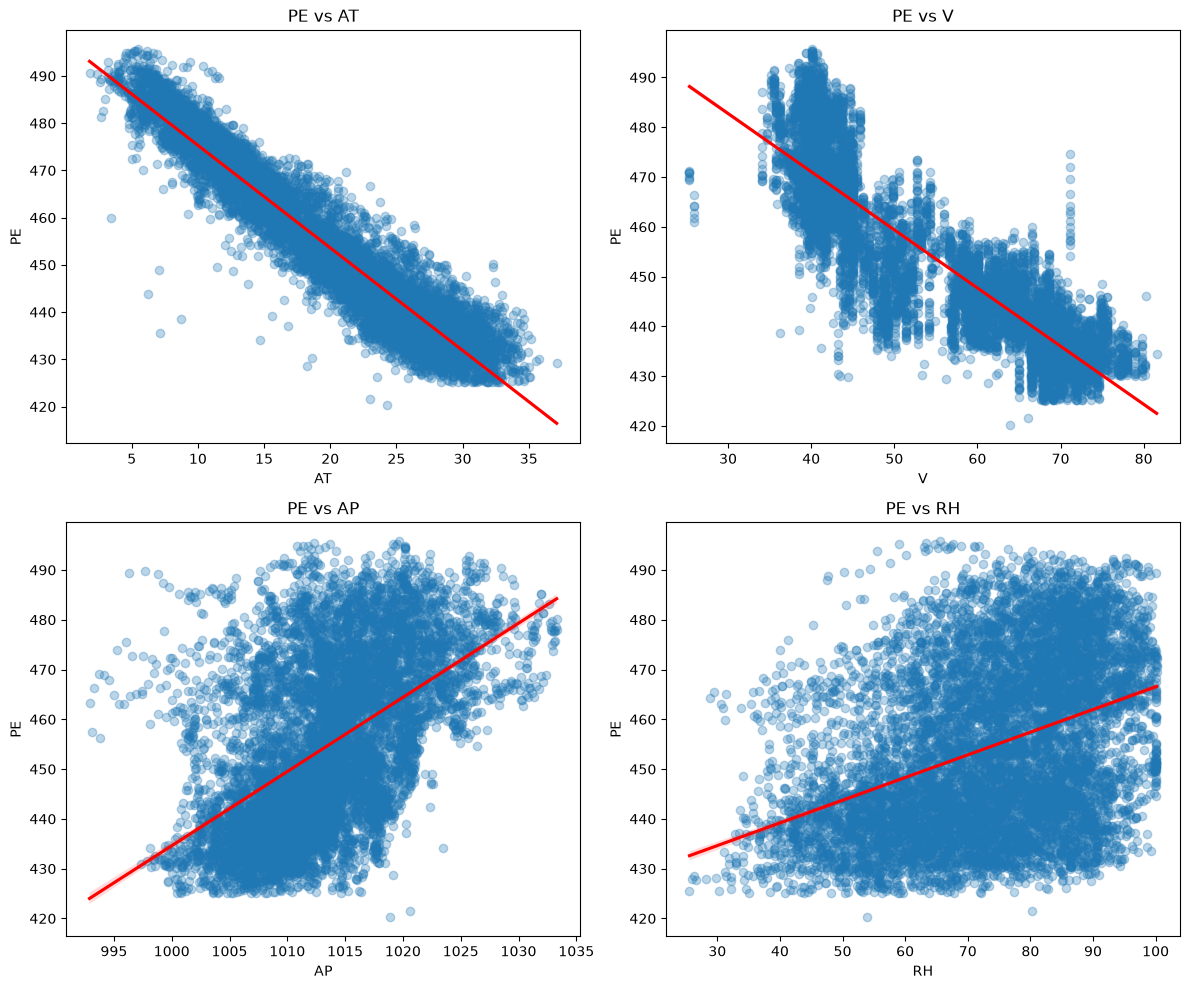

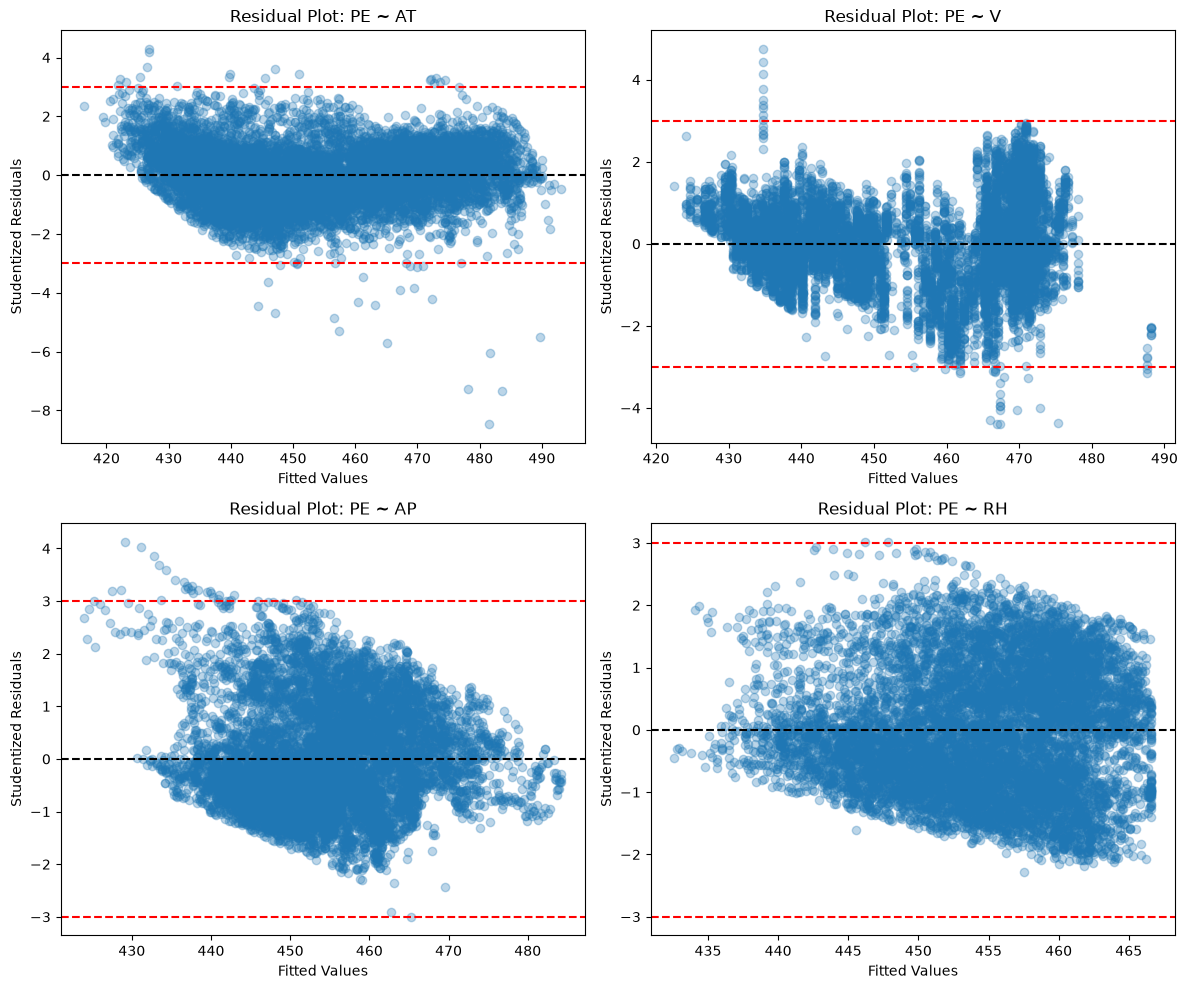

AT: 42 potential outliers
V: 33 potential outliers
AP: 29 potential outliers
RH: 2 potential outliers


In [6]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}

# Simple linear regression models
for x in predictors:
    model = smf.ols(f"PE ~ {x}", data=df).fit()
    simple_models[x] = model

    print(f"Simple Linear Regression: PE ~ {x}")
    print(model.summary())
    print("\n" + "=" * 80 + "\n")


# Regression plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, x in zip(axes.flatten(), predictors):
    sns.regplot(
        data=df,
        x=x,
        y="PE",
        ax=ax,
        scatter_kws={"alpha": 0.3},
        line_kws={"color": "red"}
    )
    ax.set_title(f"PE vs {x}")

plt.tight_layout()
plt.show()


# Studentized residual plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, x in zip(axes.flatten(), predictors):
    model = simple_models[x]
    studentized_residuals = (
        model.get_influence().resid_studentized_internal
    )

    ax.scatter(
        model.fittedvalues,
        studentized_residuals,
        alpha=0.3
    )

    ax.axhline(0, color="black", linestyle="--")
    ax.axhline(3, color="red", linestyle="--")
    ax.axhline(-3, color="red", linestyle="--")

    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Studentized Residuals")
    ax.set_title(f"Residual Plot: PE ~ {x}")

plt.tight_layout()
plt.show()


# Count potential outliers
for x in predictors:
    model = simple_models[x]
    studentized_residuals = (
        model.get_influence().resid_studentized_internal
    )

    n_outliers = np.sum(
        np.abs(studentized_residuals) > 3
    )

    print(f"{x}: {n_outliers} potential outliers")

All four predictors have statistically significant associations with PE (p < 0.001).

AT has the strongest simple linear relationship with PE, with a coefficient of -2.1713 and an R-squared of 0.899. Thus, a one-unit increase in AT is associated with an average decrease of approximately 2.17 units in PE.

V also has a strong negative association with PE (coefficient = -1.1681, R-squared = 0.757). In contrast, AP and RH have positive associations with PE, with coefficients of 1.4899 and 0.4557, respectively. Their R-squared values (0.269 for AP and 0.152 for RH) indicate substantially weaker simple linear relationships.

The regression and residual plots support these results. The relationship between AT and PE is approximately linear, whereas the residual plots for several predictors, especially V, AP, and RH, show systematic patterns, suggesting that a simple linear relationship may not fully capture the association.

Using |studentized residual| > 3 as a screening rule, there are 42 potential outliers for AT, 33 for V, 29 for AP, and 2 for RH. However, these observations are not necessarily data errors. Therefore, I would retain them rather than remove them solely based on the residual criterion.

### (d) Multiple Regression

In [7]:
multiple_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:40   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

The multiple linear regression model has an R-squared of 0.929, indicating that the four predictors together explain approximately 92.9% of the variability in PE.

All four predictors are statistically significant (p < 0.001). Therefore, we reject the null hypothesis \(H_0:\beta_j=0\) for AT, V, AP, and RH.

Holding the other predictors constant, AT and V are negatively associated with PE, AP is positively associated with PE, and RH is negatively associated with PE.

### (e) 1c Compare to 1d

,Predictor,Simple Regression Coefficient,Multiple Regression Coefficient
0,AT,-2.171320,-1.977513
1,V,-1.168135,-0.233916
2,AP,1.489872,0.062083
3,RH,0.455650,-0.158054


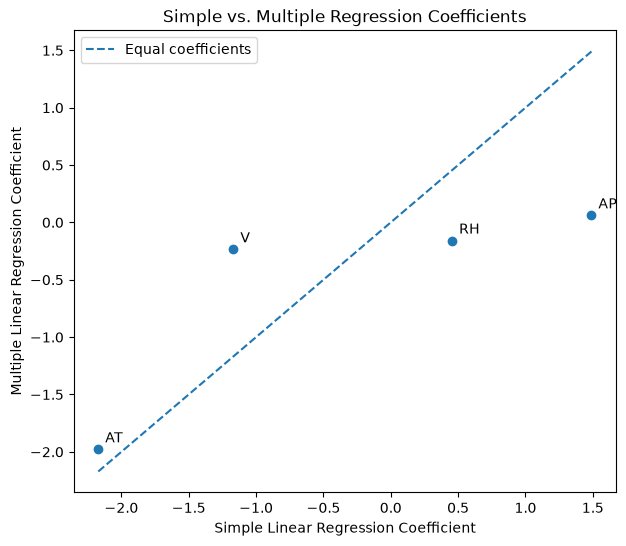

In [8]:
simple_coefs = [simple_models[x].params[x] for x in predictors]
multiple_coefs = [multiple_model.params[x] for x in predictors]

coef_comparison = pd.DataFrame({
    "Predictor": predictors,
    "Simple Regression Coefficient": simple_coefs,
    "Multiple Regression Coefficient": multiple_coefs
})

display(coef_comparison)

plt.figure(figsize=(7, 6))
plt.scatter(simple_coefs, multiple_coefs)

for i, x in enumerate(predictors):
    plt.annotate(
        x,
        (simple_coefs[i], multiple_coefs[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Reference line: simple coefficient = multiple coefficient
min_val = min(simple_coefs + multiple_coefs)
max_val = max(simple_coefs + multiple_coefs)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Equal coefficients"
)

plt.xlabel("Simple Linear Regression Coefficient")
plt.ylabel("Multiple Linear Regression Coefficient")
plt.title("Simple vs. Multiple Regression Coefficients")
plt.legend()
plt.show()

The coefficients from the simple and multiple linear regression models differ substantially for several predictors.

AT has a similar negative coefficient in both models, suggesting that its strong negative association with PE remains even after adjusting for the other predictors.

For V and AP, the magnitudes of the coefficients become much smaller in the multiple regression model. This indicates that part of their apparent association with PE in the simple regressions can be explained by their relationships with the other predictors.

The most notable change occurs for RH. Its coefficient is positive in the simple regression but becomes negative in the multiple regression model. This sign reversal suggests that the marginal relationship between RH and PE differs from its partial relationship after controlling for AT, V, and AP.

Overall, the differences between the simple and multiple regression coefficients are consistent with the correlations among the predictors observed in the pairwise scatterplots.

### (f) Nonlinear Association

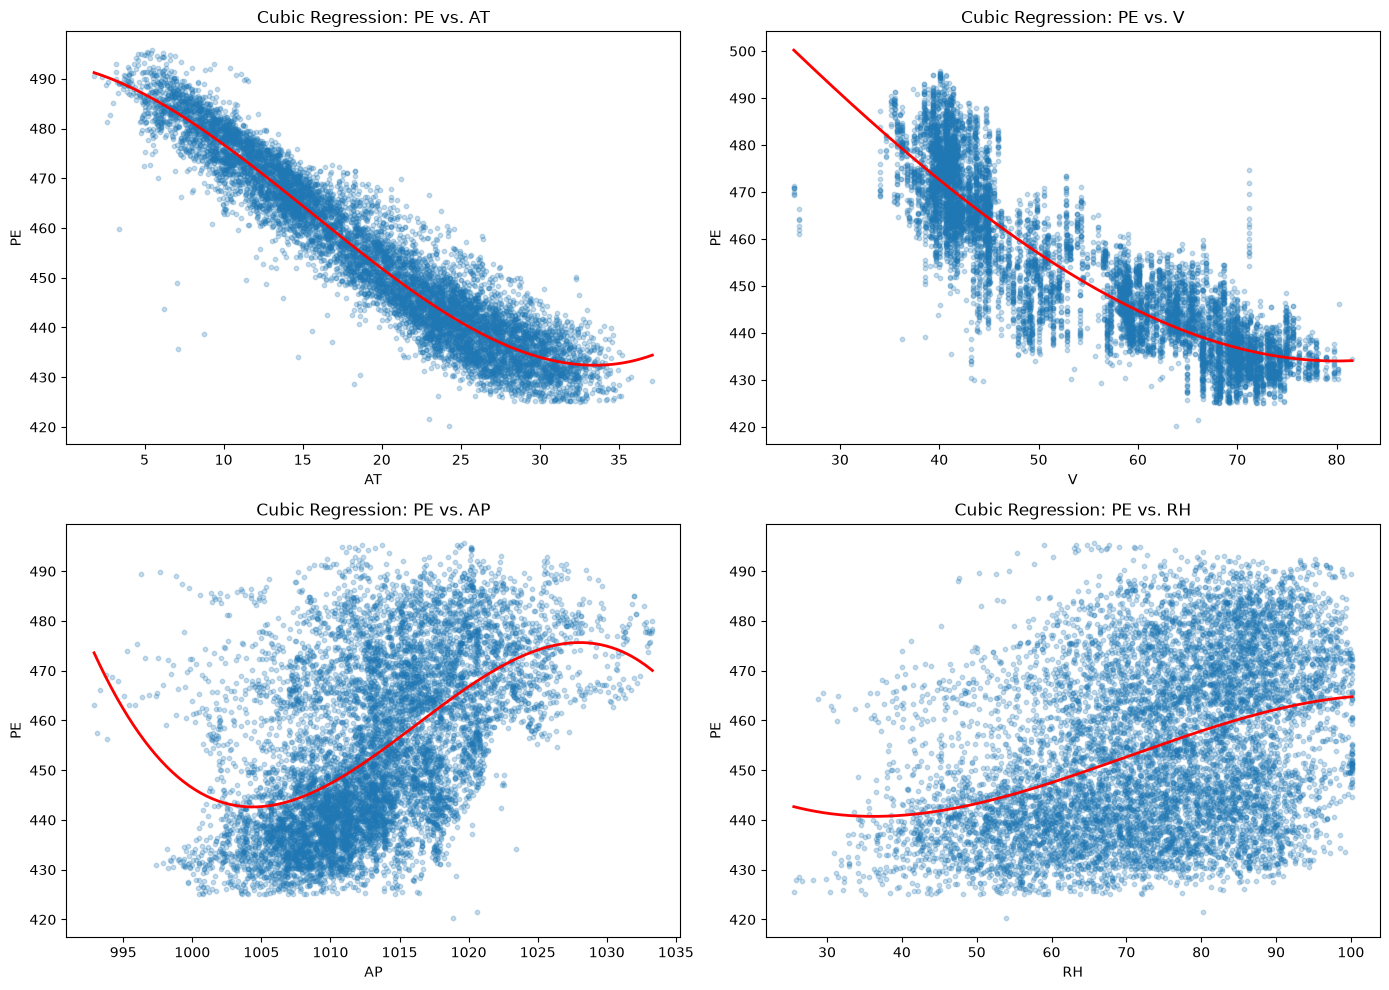

,Cubic R-squared,R-squared Improvement,Joint F-test P-value
Predictor,,,
AT,0.9119,0.0129,< 0.001
V,0.7750,0.0185,< 0.001
AP,0.2975,0.0288,< 0.001
RH,0.1537,0.0018,< 0.001


In [9]:
polynomial_models = {}
nonlinear_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    # Standardize the predictor for numerical stability
    x_mean = df[predictor].mean()
    x_std = df[predictor].std()

    standardized_x = (df[predictor] - x_mean) / x_std

    model_data = pd.DataFrame({
        "PE": df["PE"],
        "Z": standardized_x
    })

    # Linear model
    linear_model = smf.ols(
        "PE ~ Z",
        data=model_data
    ).fit()

    # Cubic polynomial model
    cubic_model = smf.ols(
        "PE ~ Z + I(Z**2) + I(Z**3)",
        data=model_data
    ).fit()

    polynomial_models[predictor] = cubic_model

    # Joint F-test: H0 = quadratic and cubic terms are both zero
    f_stat, p_value, df_diff = cubic_model.compare_f_test(linear_model)

    nonlinear_results.append({
        "Predictor": predictor,
        "Cubic R-squared": cubic_model.rsquared,
        "R-squared Improvement":
            cubic_model.rsquared - linear_model.rsquared,
        "Joint F-test P-value": p_value
    })

    # Smooth grid in original predictor units
    x_grid = np.linspace(
        df[predictor].min(),
        df[predictor].max(),
        300
    )

    prediction_data = pd.DataFrame({
        "Z": (x_grid - x_mean) / x_std
    })

    predicted_pe = cubic_model.predict(prediction_data)

    axes[i].scatter(
        df[predictor],
        df["PE"],
        alpha=0.25,
        s=10
    )

    axes[i].plot(
        x_grid,
        predicted_pe,
        color="red",
        linewidth=2
    )

    axes[i].set_title(f"Cubic Regression: PE vs. {predictor}")
    axes[i].set_xlabel(predictor)
    axes[i].set_ylabel("PE")

plt.tight_layout()
plt.show()


# Summary table
nonlinear_summary = pd.DataFrame(
    nonlinear_results
).set_index("Predictor")

nonlinear_summary["Cubic R-squared"] = (
    nonlinear_summary["Cubic R-squared"].round(4)
)

nonlinear_summary["R-squared Improvement"] = (
    nonlinear_summary["R-squared Improvement"].round(4)
)

nonlinear_summary["Joint F-test P-value"] = (
    nonlinear_summary["Joint F-test P-value"]
    .apply(lambda p: "< 0.001" if p < 0.001 else f"{p:.4f}")
)

display(nonlinear_summary)

There is evidence of nonlinear association between PE and all four predictors.

For each predictor, a cubic polynomial model was fitted after standardizing the predictor to improve numerical stability. The cubic model was compared with the corresponding linear model using a joint F-test of

$$
H_0:\beta_2=\beta_3=0.
$$

The joint F-test p-values are less than 0.001 for AT, V, AP, and RH. Therefore, we reject the null hypothesis for all four predictors and conclude that each predictor shows evidence of a nonlinear association with PE.

The increase in R-squared is more noticeable for AT, V, and AP, while the improvement for RH is relatively small. Thus, the nonlinear terms for RH are statistically significant but provide only a small improvement in explanatory power.

### (g) Interactions of Predictors

In [10]:
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:41   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

Four of the six pairwise interaction terms are statistically significant at the 0.05 level.

The significant interactions are AT:V (p < 0.001), AT:RH (p < 0.001), V:AP (p < 0.001), and AP:RH (p = 0.034).

The interactions AT:AP (p = 0.452) and V:RH (p = 0.086) are not statistically significant.

These results suggest that the association between some predictors and PE depends on the values of other predictors.

### (h) Improvement

In [11]:
# 70/30 train-test split
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)


# Baseline multiple linear regression
baseline_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_df
).fit()

train_pred_baseline = baseline_model.predict(train_df)
test_pred_baseline = baseline_model.predict(test_df)

baseline_train_mse = mean_squared_error(
    train_df["PE"],
    train_pred_baseline
)

baseline_test_mse = mean_squared_error(
    test_df["PE"],
    test_pred_baseline
)

print(f"Baseline Train MSE: {baseline_train_mse:.4f}")
print(f"Baseline Test MSE: {baseline_test_mse:.4f}")


# Full model with quadratic terms and interactions
full_model = smf.ols(
    """
    PE ~ AT + V + AP + RH
       + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)
       + AT:V + AT:AP + AT:RH
       + V:AP + V:RH
       + AP:RH
    """,
    data=train_df
).fit()

print("\nFull Model P-values:")
print(full_model.pvalues)


# Reduced model after removing insignificant higher-order terms
# while preserving hierarchy
reduced_model = smf.ols(
    """
    PE ~ AT + V + AP + RH
       + I(AT**2) + I(AP**2) + I(RH**2)
       + AT:V + AT:RH + AP:RH
    """,
    data=train_df
).fit()

print("\nReduced Model:")
print(reduced_model.summary())


# Reduced model MSEs
train_pred_reduced = reduced_model.predict(train_df)
test_pred_reduced = reduced_model.predict(test_df)

reduced_train_mse = mean_squared_error(
    train_df["PE"],
    train_pred_reduced
)

reduced_test_mse = mean_squared_error(
    test_df["PE"],
    test_pred_reduced
)

print(f"\nReduced Model Train MSE: {reduced_train_mse:.4f}")
print(f"Reduced Model Test MSE: {reduced_test_mse:.4f}")

Baseline Train MSE: 20.5808
Baseline Test MSE: 21.2399

Full Model P-values:
Intercept     8.518151e-08
AT            4.460633e-02
V             2.671816e-01
AP            9.534685e-09
RH            1.429286e-04
I(AT ** 2)    5.017196e-07
I(V ** 2)     6.998020e-01
I(AP ** 2)    8.522142e-09
I(RH ** 2)    1.395087e-09
AT:V          3.195237e-03
AT:AP         1.966307e-01
AT:RH         3.056335e-03
V:AP          3.811800e-01
V:RH          8.673824e-01
AP:RH         2.937919e-04
dtype: float64

Reduced Model:
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:41   Log-Likelihood:                -19166.
No. Observati

The baseline multiple linear regression model achieved a training MSE of 20.5808 and a test MSE of 21.2399.

After including quadratic terms and pairwise interactions, insignificant higher-order terms were removed based on their p-values while maintaining the hierarchy principle. The reduced model retained AT², AP², RH², AT:V, AT:RH, and AP:RH, together with all required main effects.

The reduced model achieved a training MSE of 17.9178 and a test MSE of 18.6943.

Since both the training and test MSEs are lower than those of the baseline model, the reduced nonlinear and interaction model provides improved predictive performance.

### (i) KNN

Best k for raw features: 5
Minimum raw test MSE: 15.7268

Best k for normalized features: 4
Minimum normalized test MSE: 14.3057


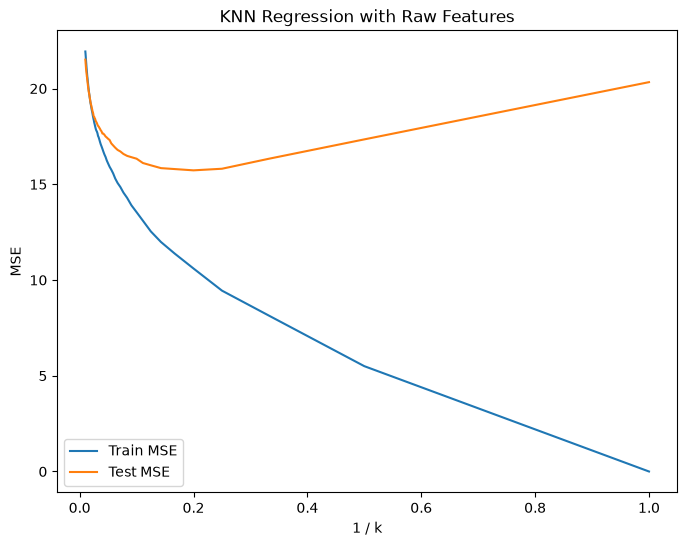

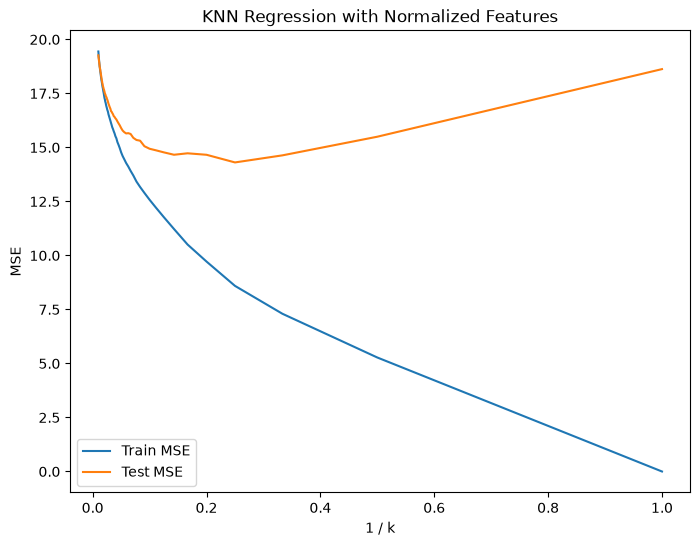

In [12]:
X_train = train_df[["AT", "V", "AP", "RH"]]
y_train = train_df["PE"]

X_test = test_df[["AT", "V", "AP", "RH"]]
y_test = test_df["PE"]

k_values = range(1, 101)


# KNN with raw features
raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )

    raw_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

best_k_raw = k_values[np.argmin(raw_test_mse)]

print(f"Best k for raw features: {best_k_raw}")
print(f"Minimum raw test MSE: {min(raw_test_mse):.4f}")


# KNN with normalized features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

norm_train_mse = []
norm_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    norm_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )

    norm_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

best_k_norm = k_values[np.argmin(norm_test_mse)]

print(f"\nBest k for normalized features: {best_k_norm}")
print(
    f"Minimum normalized test MSE: "
    f"{min(norm_test_mse):.4f}"
)


# Plot train/test errors versus 1/k
inverse_k = [1 / k for k in k_values]

plt.figure(figsize=(8, 6))
plt.plot(inverse_k, raw_train_mse, label="Train MSE")
plt.plot(inverse_k, raw_test_mse, label="Test MSE")
plt.xlabel("1 / k")
plt.ylabel("MSE")
plt.title("KNN Regression with Raw Features")
plt.legend()
plt.show()


plt.figure(figsize=(8, 6))
plt.plot(inverse_k, norm_train_mse, label="Train MSE")
plt.plot(inverse_k, norm_test_mse, label="Test MSE")
plt.xlabel("1 / k")
plt.ylabel("MSE")
plt.title("KNN Regression with Normalized Features")
plt.legend()
plt.show()

For KNN regression using the raw features, the best value is \(k=5\), with a minimum test MSE of 15.7268.

After standardizing the predictors, the best value is \(k=4\), with a lower minimum test MSE of 14.3057.

The normalized KNN model performs better than the raw-feature KNN model. This is expected because KNN relies on distances between observations, and standardization prevents variables with larger numerical scales from dominating the distance calculation.

The train and test error curves also illustrate the bias-variance tradeoff. Very small values of \(k\) produce highly flexible models with very low training error but higher test error, while larger values of \(k\) produce smoother models.

### (j ) Compare KNN and Linear

The best linear-regression-based model is the reduced nonlinear and interaction model, with a test MSE of 18.6943.

The best KNN regression model uses normalized features with \(k=4\), and has a lower test MSE of 14.3057.

Therefore, KNN provides better predictive performance on the test set for this dataset.

This suggests that the relationship between the predictors and PE may contain local or nonlinear structure that is not fully captured by the regression model, even after including quadratic terms and interactions.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Better.

When \(n\) is very large and \(p\) is small, there is enough data to estimate a more flexible model reliably. The variance of the fitted model is less of a concern, so the lower bias of a flexible method can improve performance.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Worse.

When \(p\) is very large and \(n\) is small, a flexible method is more likely to overfit the training data. This results in high variance and poorer test performance than a less flexible method.

### (c) The relationship between the predictors and response is highly non-linear.

Better.

When the true relationship between the predictors and the response is highly non-linear, a flexible method is better able to capture the complex relationship. An inflexible method would tend to have higher bias.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Worse.

When the error variance is extremely high, much of the variation in the response is noise. A flexible method may fit this noise, leading to high variance and overfitting. A less flexible method would generally perform better.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distances from the test point $(0,0,0)$ are:

| Observation | Euclidean Distance |
|---|---|
| 1 | $3$ |
| 2 | $2$ |
| 3 | $\sqrt{10} \approx 3.162$ |
| 4 | $\sqrt{5} \approx 2.236$ |
| 5 | $\sqrt{2} \approx 1.414$ |
| 6 | $\sqrt{3} \approx 1.732$ |

### (b) What is our prediction with K = 1? Why?

With \(K=1\), the prediction is **Green**, because Observation 5 is the single nearest neighbor to the test point.

### (c) What is our prediction with K = 3? Why?

With \(K=3\), the prediction is **Red**.

The three nearest neighbors are Observations 5, 6, and 2, with class labels Green, Red, and Red. Since Red is the majority class, the predicted response is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the best value of \(K\) to be small.

A small \(K\) makes the KNN classifier more flexible, allowing it to capture a highly non-linear decision boundary. A large \(K\) would produce a smoother and less flexible boundary and could have high bias.